# Investigating the Impact of Noise and Outliers on Support Vector Machine Decision Boundaries

Github Link:https://github.com/KARTHIK-363/24109604

This notebook investigates how noise and outliers affect the behaviour of Support Vector Machine (SVM) classifiers. The study compares SVM decision boundaries on clean data, noisy data, and data containing outliers.

The main objectives are:

- To visualise how noise changes SVM decision boundaries
- To examine how outliers influence support vectors
- To evaluate classification performance under different levels of data contamination
- To study how the regularisation parameter `C` affects robustness

This analysis uses synthetic datasets generated with `scikit-learn` and visualises results using `matplotlib`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

## 1. Generate the Baseline Dataset

We begin by generating a clean synthetic dataset using the `make_moons` function. This dataset is useful because it is non-linearly separable, making it suitable for demonstrating how SVM behaves under different data conditions.


In [ ]:
# Reproducibility
np.random.seed(42)

# Generate clean dataset
X_clean, y_clean = make_moons(n_samples=300, noise=0.15, random_state=42)

print("Dataset shape:", X_clean.shape)
print("Class labels:", np.unique(y_clean))

Dataset shape: (300, 2)
Class labels: [0 1]


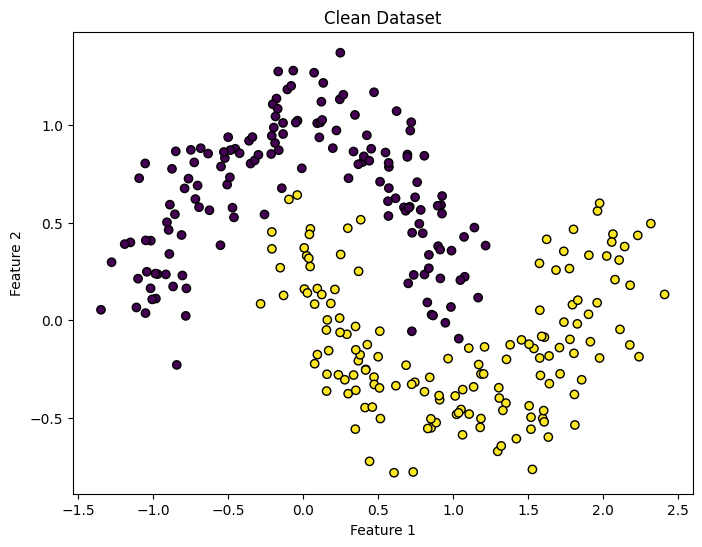

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_clean[:, 0], X_clean[:, 1], c=y_clean, edgecolors='k')
plt.title("Clean Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 2. Train an SVM on the Clean Dataset

An SVM with an RBF kernel is trained on the clean dataset to establish a baseline. The model is expected to produce a smooth non-linear decision boundary that follows the curved structure of the data.


In [ ]:
# Train-test split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42, stratify=y_clean
)

# Feature scaling
scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

# Train SVM
svm_clean = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_clean.fit(X_train_clean_scaled, y_train_clean)

# Predictions
y_pred_clean = svm_clean.predict(X_test_clean_scaled)

# Accuracy
acc_clean = accuracy_score(y_test_clean, y_pred_clean)
print(f"Clean data accuracy: {acc_clean:.4f}")

Clean data accuracy: 0.9333


In [ ]:
def plot_decision_boundary(model, X, y, scaler=None, title="Decision Boundary", show_support=True):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    if scaler is not None:
        grid_scaled = scaler.transform(grid)
    else:
        grid_scaled = grid

    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.contour(xx, yy, Z, levels=[0.5], linewidths=2)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    if show_support:
        if scaler is not None:
            support_vectors_original = scaler.inverse_transform(model.support_vectors_)
        else:
            support_vectors_original = model.support_vectors_
        plt.scatter(
            support_vectors_original[:, 0],
            support_vectors_original[:, 1],
            s=120,
            facecolors='none',
            edgecolors='k',
            linewidths=1.5,
            label='Support Vectors'
        )
        plt.legend()

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

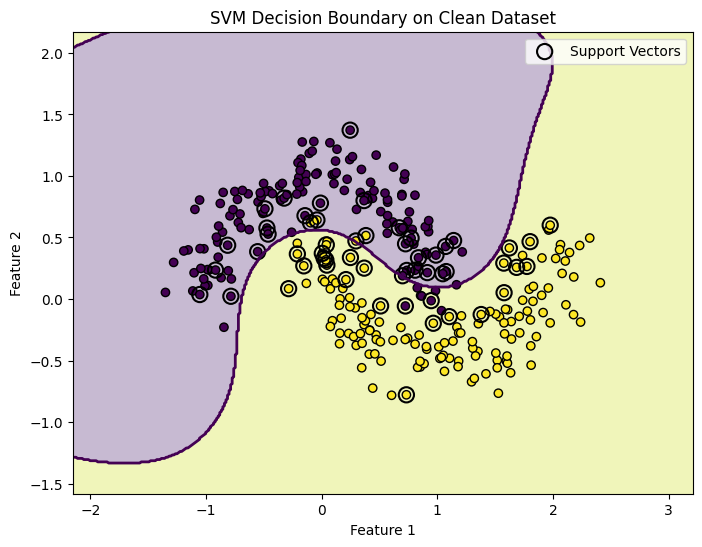

In [ ]:
plot_decision_boundary(
    svm_clean,
    X_clean,
    y_clean,
    scaler=scaler_clean,
    title="SVM Decision Boundary on Clean Dataset"
)

## 3. Introduce Additional Feature Noise

Next, extra feature noise is added to the dataset. This simulates real-world measurement errors or random fluctuations in the input features.

The purpose is to observe how the SVM boundary changes when the input data becomes less clean.


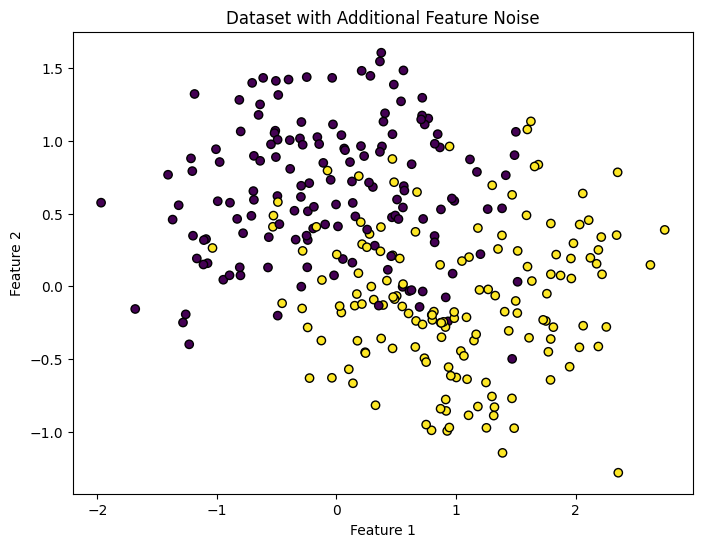

In [ ]:
# Add additional Gaussian feature noise
noise_strength = 0.35
X_noisy = X_clean + np.random.normal(0, noise_strength, X_clean.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_clean, edgecolors='k')
plt.title("Dataset with Additional Feature Noise")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
    X_noisy, y_clean, test_size=0.3, random_state=42, stratify=y_clean
)

scaler_noisy = StandardScaler()
X_train_noisy_scaled = scaler_noisy.fit_transform(X_train_noisy)
X_test_noisy_scaled = scaler_noisy.transform(X_test_noisy)

svm_noisy = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_noisy.fit(X_train_noisy_scaled, y_train_noisy)

y_pred_noisy = svm_noisy.predict(X_test_noisy_scaled)
acc_noisy = accuracy_score(y_test_noisy, y_pred_noisy)

print(f"Noisy data accuracy: {acc_noisy:.4f}")

Noisy data accuracy: 0.8444


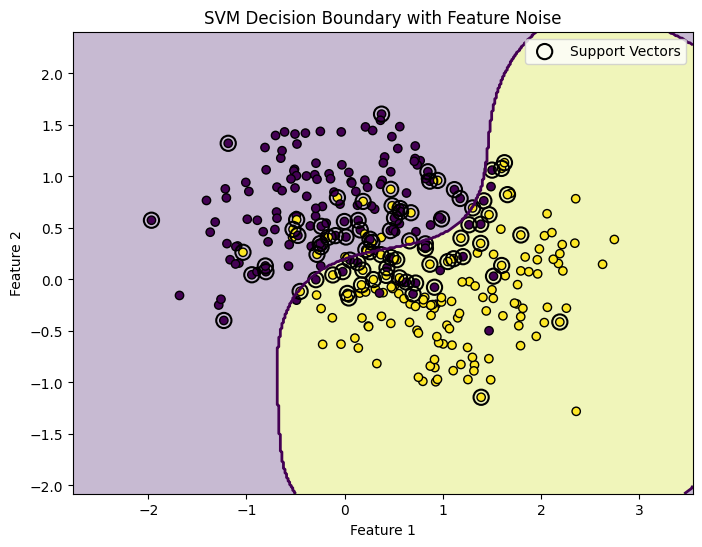

In [ ]:
plot_decision_boundary(
    svm_noisy,
    X_noisy,
    y_clean,
    scaler=scaler_noisy,
    title="SVM Decision Boundary with Feature Noise"
)

## 4. Introduce Outliers

Outliers are data points that lie far away from the main class clusters. These points are particularly important for SVM because they can become support vectors and strongly influence the decision boundary.

Here, artificial outliers are added to both classes.


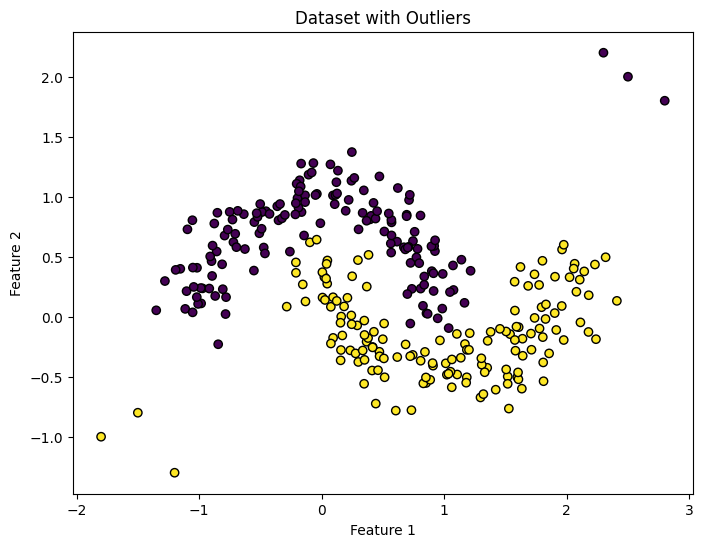

In [ ]:
# Create outliers manually
outliers_class_0 = np.array([[2.5, 2.0], [2.8, 1.8], [2.3, 2.2]])
outliers_class_1 = np.array([[-1.5, -0.8], [-1.8, -1.0], [-1.2, -1.3]])

X_outliers = np.vstack([X_clean, outliers_class_0, outliers_class_1])
y_outliers = np.hstack([y_clean, np.zeros(len(outliers_class_0)), np.ones(len(outliers_class_1))])

plt.figure(figsize=(8, 6))
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c=y_outliers, edgecolors='k')
plt.title("Dataset with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_outliers, y_outliers, test_size=0.3, random_state=42, stratify=y_outliers
)

scaler_out = StandardScaler()
X_train_out_scaled = scaler_out.fit_transform(X_train_out)
X_test_out_scaled = scaler_out.transform(X_test_out)

svm_out = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_out.fit(X_train_out_scaled, y_train_out)

y_pred_out = svm_out.predict(X_test_out_scaled)
acc_out = accuracy_score(y_test_out, y_pred_out)

print(f"Outlier data accuracy: {acc_out:.4f}")


Outlier data accuracy: 0.9348


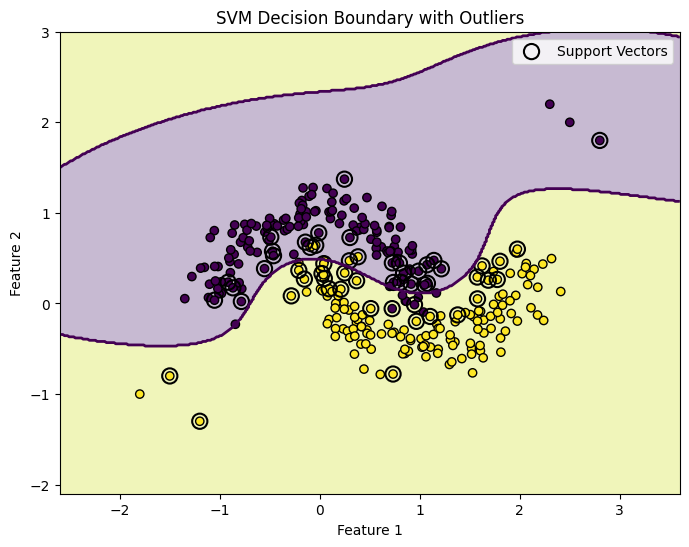

In [ ]:
plot_decision_boundary(
    svm_out,
    X_outliers,
    y_outliers,
    scaler=scaler_out,
    title="SVM Decision Boundary with Outliers"
)

## 5. Compare Clean, Noisy, and Outlier Scenarios

This section compares the three scenarios side by side:

- Clean dataset
- Noisy dataset
- Dataset with outliers

This visual comparison helps reveal how the decision boundary becomes more distorted as data quality decreases.


In [ ]:
def plot_boundary_subplot(ax, model, X, y, scaler, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = model.predict(grid_scaled).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0.5], linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    support_vectors_original = scaler.inverse_transform(model.support_vectors_)
    ax.scatter(
        support_vectors_original[:, 0],
        support_vectors_original[:, 1],
        s=90,
        facecolors='none',
        edgecolors='k',
        linewidths=1.2
    )

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

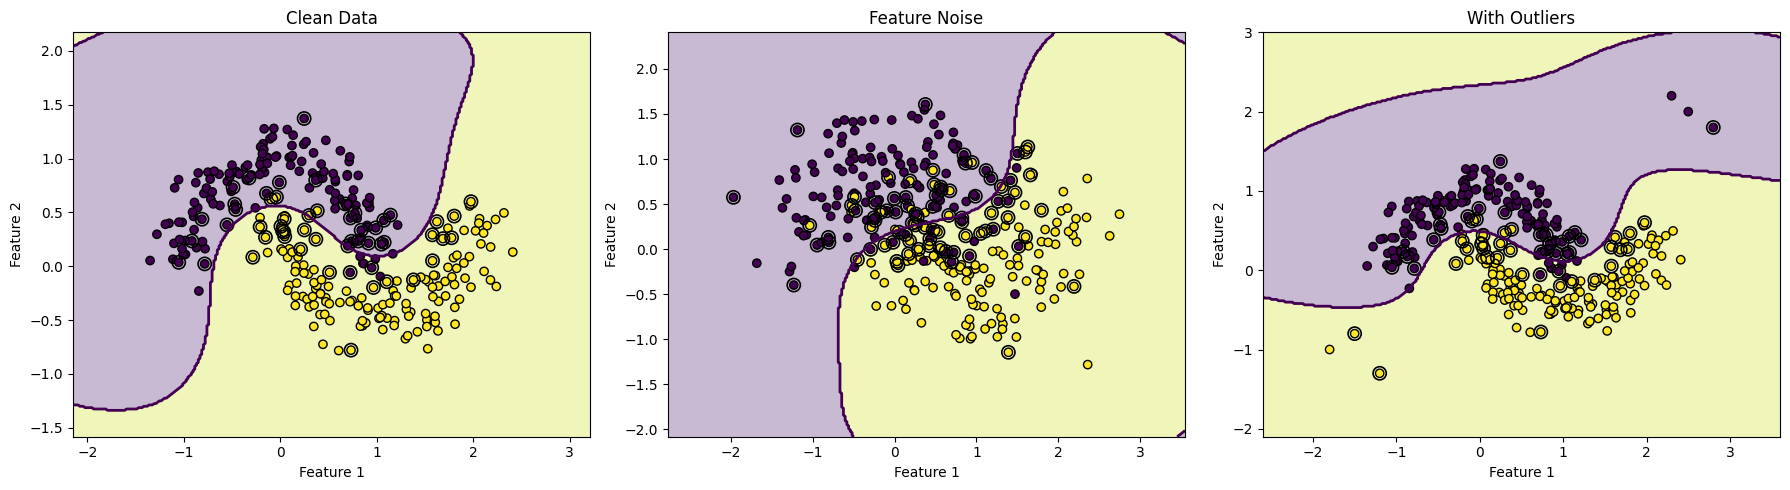

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_boundary_subplot(axes[0], svm_clean, X_clean, y_clean, scaler_clean, "Clean Data")
plot_boundary_subplot(axes[1], svm_noisy, X_noisy, y_clean, scaler_noisy, "Feature Noise")
plot_boundary_subplot(axes[2], svm_out, X_outliers, y_outliers, scaler_out, "With Outliers")

plt.tight_layout()
plt.show()

## 6. Compare Model Accuracy Across Conditions

To quantify the effect of data contamination, the classification accuracy is compared across the clean, noisy, and outlier datasets.


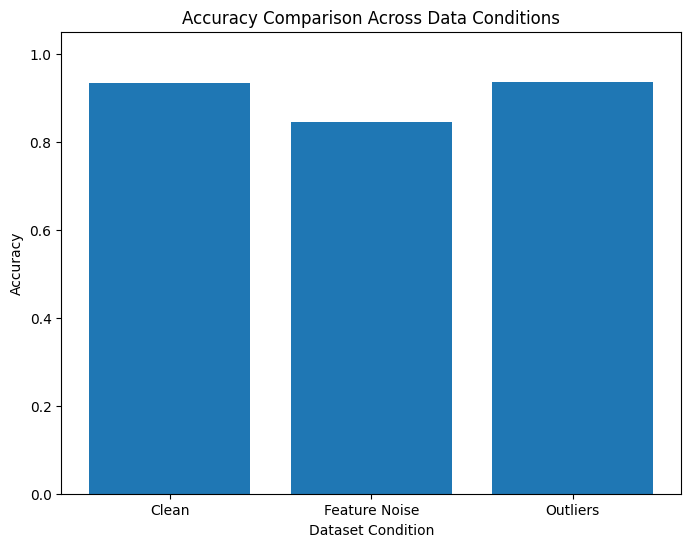

Clean: 0.9333
Feature Noise: 0.8444
Outliers: 0.9348


In [ ]:
conditions = ["Clean", "Feature Noise", "Outliers"]
accuracies = [acc_clean, acc_noisy, acc_out]

plt.figure(figsize=(8, 6))
plt.bar(conditions, accuracies)
plt.ylim(0, 1.05)
plt.title("Accuracy Comparison Across Data Conditions")
plt.xlabel("Dataset Condition")
plt.ylabel("Accuracy")
plt.show()

for condition, acc in zip(conditions, accuracies):
    print(f"{condition}: {acc:.4f}")

## 7. Analyse the Number of Support Vectors

Because SVM is defined by support vectors, it is useful to compare how many support vectors are selected in each scenario.

An increase in support vectors often suggests a more complex or less stable boundary.


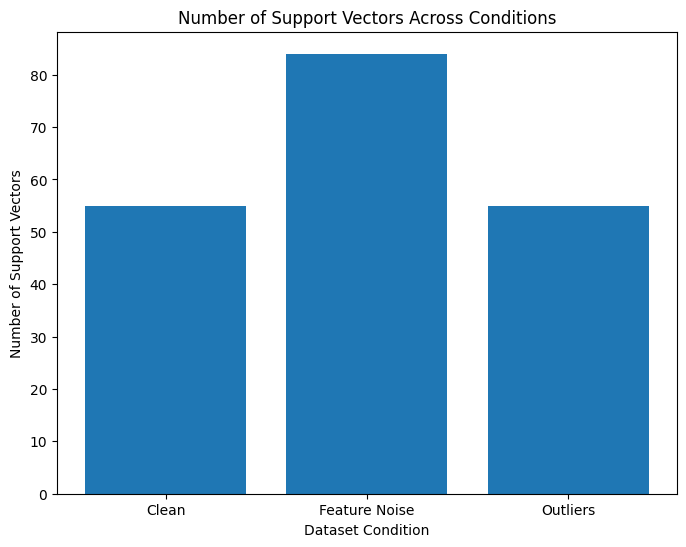

Clean: 55 support vectors
Feature Noise: 84 support vectors
Outliers: 55 support vectors


In [ ]:
support_vector_counts = [
    len(svm_clean.support_vectors_),
    len(svm_noisy.support_vectors_),
    len(svm_out.support_vectors_)
]

plt.figure(figsize=(8, 6))
plt.bar(conditions, support_vector_counts)
plt.title("Number of Support Vectors Across Conditions")
plt.xlabel("Dataset Condition")
plt.ylabel("Number of Support Vectors")
plt.show()

for condition, count in zip(conditions, support_vector_counts):
    print(f"{condition}: {count} support vectors")

## 8. Study the Effect of the Regularisation Parameter C

The regularisation parameter `C` controls the trade-off between margin width and classification error.

- A small `C` allows more misclassification and produces a smoother boundary
- A large `C` penalises misclassification more strongly and can become sensitive to noise

This experiment tests multiple values of `C` on the outlier dataset.


In [ ]:
C_values = [0.1, 1, 10, 100]
models_C = []
acc_C = []

for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale')
    model.fit(X_train_out_scaled, y_train_out)
    y_pred = model.predict(X_test_out_scaled)
    acc = accuracy_score(y_test_out, y_pred)

    models_C.append(model)
    acc_C.append(acc)

    print(f"C = {c}: Accuracy = {acc:.4f}")

C = 0.1: Accuracy = 0.8696
C = 1: Accuracy = 0.9348
C = 10: Accuracy = 0.9891
C = 100: Accuracy = 0.9674


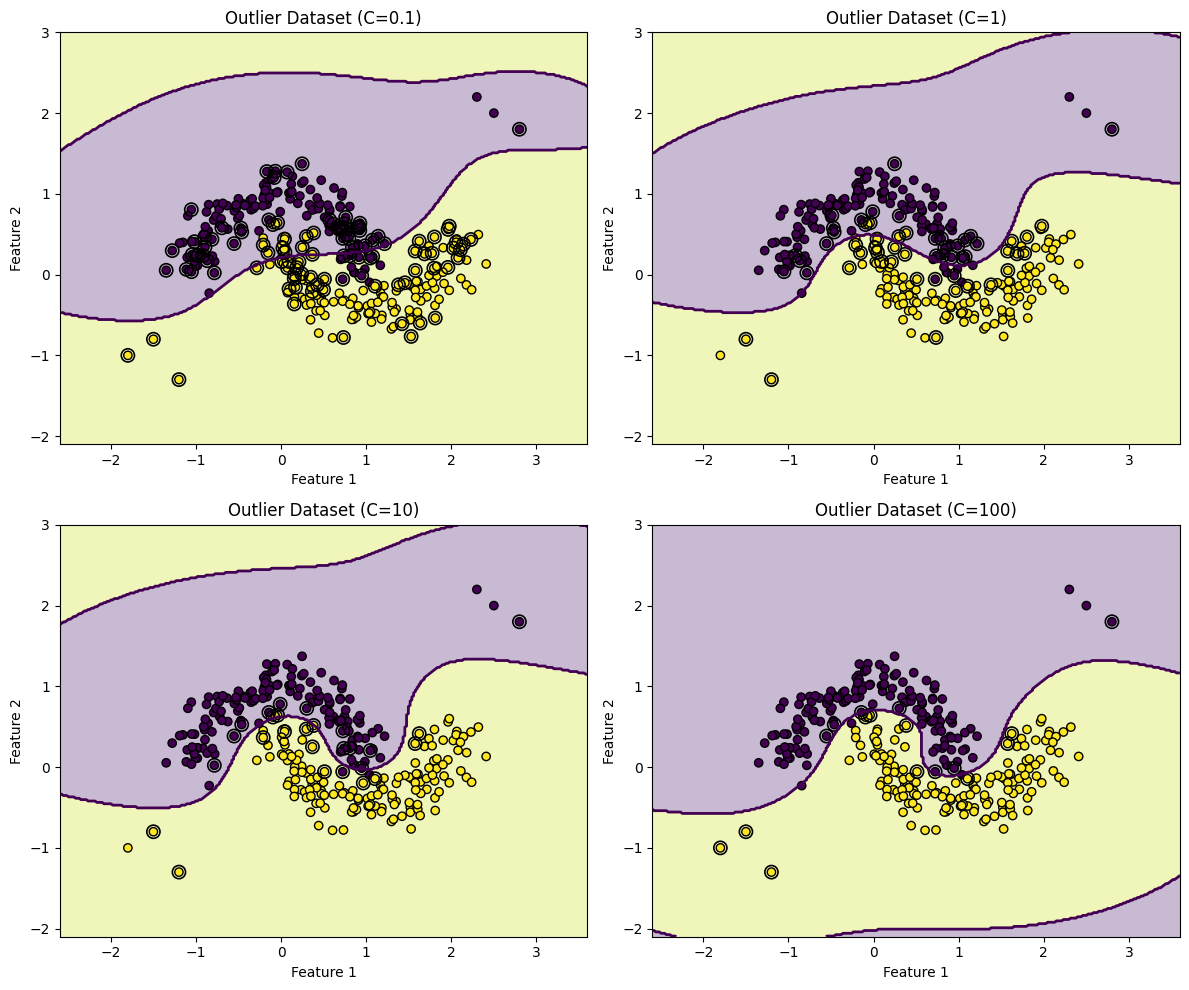

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, c in enumerate(C_values):
    plot_boundary_subplot(
        axes[i],
        models_C[i],
        X_outliers,
        y_outliers,
        scaler_out,
        f"Outlier Dataset (C={c})"
    )

plt.tight_layout()
plt.show()

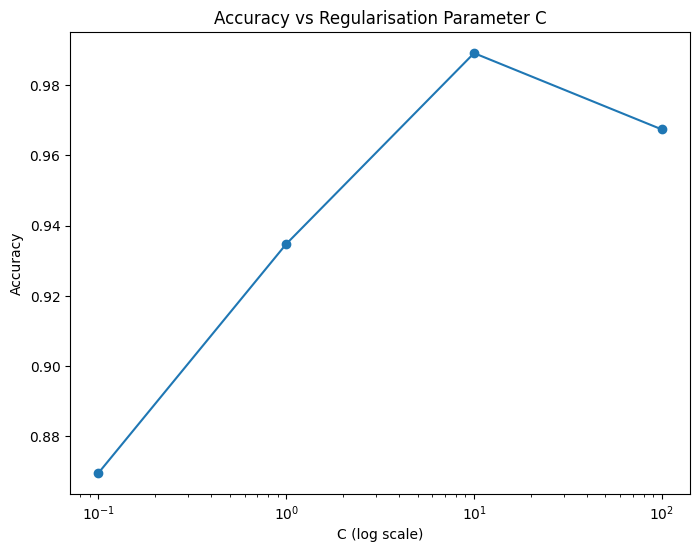

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(C_values, acc_C, marker='o')
plt.xscale('log')
plt.title("Accuracy vs Regularisation Parameter C")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.show()

## 9. Classification Report for the Best Outlier Model

This section prints a detailed classification report for the best-performing model on the outlier dataset.

In [ ]:
best_index = int(np.argmax(acc_C))
best_model = models_C[best_index]
best_C = C_values[best_index]

best_pred = best_model.predict(X_test_out_scaled)

print(f"Best C value: {best_C}")
print("\nClassification Report:\n")
print(classification_report(y_test_out, best_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_out, best_pred))

Best C value: 10

Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        46
         1.0       0.98      1.00      0.99        46

    accuracy                           0.99        92
   macro avg       0.99      0.99      0.99        92
weighted avg       0.99      0.99      0.99        92

Confusion Matrix:
[[45  1]
 [ 0 46]]


## 10. Summary of Findings

The notebook demonstrates several important observations:

1. On clean data, SVM produces a smooth and effective decision boundary.
2. Feature noise makes the boundary less stable and can reduce classification accuracy.
3. Outliers can strongly distort the boundary because they often become support vectors.
4. The number of support vectors tends to increase when data quality worsens.
5. The regularisation parameter `C` plays an important role in controlling robustness.

These findings show that although SVM is a powerful classifier, its behaviour is strongly influenced by the quality of the data and the choice of hyperparameters.


## 11. Conclusion

This study investigated the impact of noise and outliers on Support Vector Machine decision boundaries using synthetic data. The results showed that both noise and outliers affect the shape of the boundary, the number of support vectors, and the overall predictive performance.

Outliers were found to have a particularly strong effect because SVM relies on support vectors to define the classification margin. In addition, the analysis showed that the regularisation parameter `C` can reduce or amplify sensitivity to contaminated data.

Overall, this notebook highlights the importance of robust preprocessing, careful data inspection, and hyperparameter tuning when applying SVM to real-world classification tasks.
